# PySpectrum Example 
## spectrum calibration.
In this example we show how to do the energy and fwhm calibration. 
Specifically we use the DetectorCalibration class here\
However, the calibration can be more specfic and optimized by the user.

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Create calibrated Spectrum 
from pyspectrum.core import Spectrum, Domain
from pyspectrum.calibration.detector_calibration import DetectorCalibration, StandardHPGeFWHMModel, PolynomialEnergyModel
from pyspectrum.background.snip import SNIPBackground
from pyspectrum.domain_analysis.background import domain_erf_background
from pyspectrum.domain_analysis.background import domain_linear_background

from pyspectrum.domain_analysis.morphology import peak_positions, find_domain_peaks

# Loading a new spectrum
The spectrum is of Eu152, and there was not calibration yet.

In [2]:
path = '../Library/152Eu_calsource_10cm_85ks.txt'
spectrum = pd.read_csv(path, names=['counts'])
first_non_zero = np.where(spectrum["counts"]>0)[0][0]
#first_non_zero = 0
spectrum = spectrum[first_non_zero:].reset_index(drop=True)
spectrum['channel'] = spectrum.index

spectrum = Spectrum.from_dataframe(df=spectrum, channel_col="channel", counts_col="counts")

In [3]:
spectrum

<xarray.DataArray (channel: 8109)>
array([19919, 25115, 26717, ...,     3,     4,     3], dtype=int64)
Coordinates:
  * channel  (channel) int64 0 1 2 3 4 5 6 ... 8103 8104 8105 8106 8107 8108

Text(0, 0.5, 'Counts')

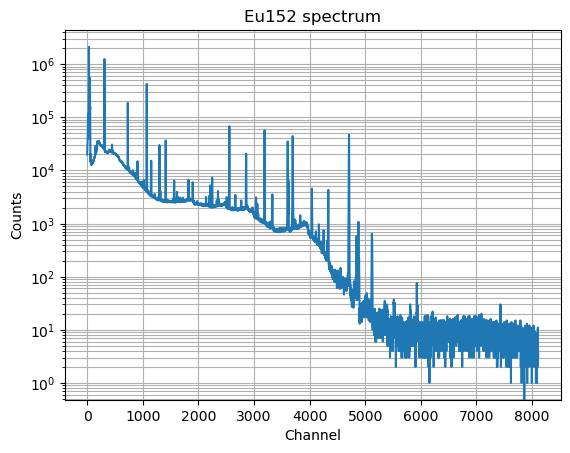

In [4]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Channel')
plt.ylabel('Counts')

## calibration generator

choose the obvious photobpeaks in the spectrum

uncomment here if you wat to see the what are the dominenent peaks in the spectrum

In [6]:
# the domain after adding the first_non_zero
domains = [(300,320),(1057,1082),(2544,2567),(3177,3202),(3597,3612),(3687,3707),(4687,4727)]
energies = [121.78, 344.28, 778.9, 964.08, 1085.8370, 1112.0760, 1408]
detector_calibration = DetectorCalibration(spectrum,
                                           known_axis_values=energies, peak_domains=domains,
                                          energy_model=PolynomialEnergyModel(2), fwhm_model=StandardHPGeFWHMModel())

In [7]:
energy_calib, fwhm_calib = detector_calibration.generate(energy_p0=(0,1,0), fwhm_p0=(0,1,0))

In [8]:
spectrum.set_axis_calibration(energy_calib)
spectrum.set_resolution_calibration(fwhm_calib)

Text(0, 0.5, 'Counts')

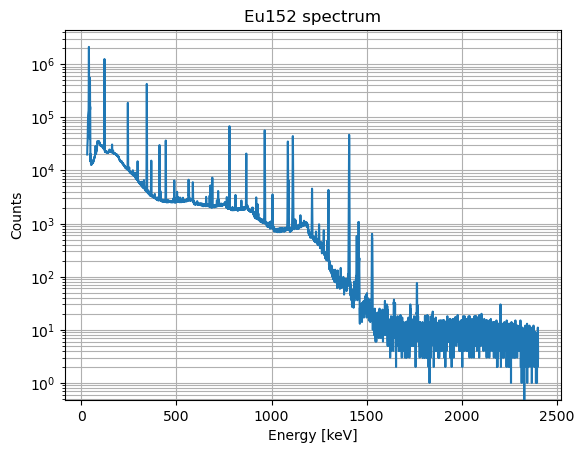

In [9]:
spectrum.plot(yscale='log')
plt.grid(True, which='both')
plt.title('Eu152 spectrum')
plt.xlabel('Energy [keV]')
plt.ylabel('Counts')

find the calibration

In [10]:
detector_calibration = DetectorCalibration(spectrum,
                                           known_axis_values=energies, peak_domains=domains,
                                          energy_model=PolynomialEnergyModel(2), fwhm_model=StandardHPGeFWHMModel())
peaks_center_ch, fwhm_val = detector_calibration.estimate_peaks()

In [11]:
fwhm_energy_val = [spectrum.axis[int(ch_center+fwhm_val[i])]-spectrum.axis[int(ch_center)] for i, ch_center in enumerate(np.round(peaks_center_ch))]

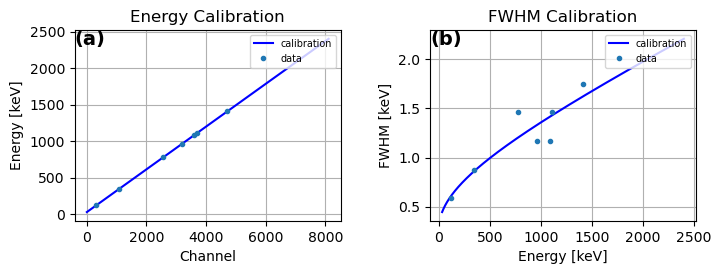

In [12]:
# === Create Side-by-Side Figure ===
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(7.1, 2.625), constrained_layout=True, gridspec_kw={'wspace': 0.1} )

# === Left plot: Energy Calibration ===
ax1.plot(spectrum.channels, spectrum.axis_calib.apply(spectrum.channels), 'b-', label='calibration')
ax1.plot(peaks_center_ch, spectrum.axis_calib.apply(peaks_center_ch), marker='.', ls='', label='data')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Energy [keV]')
ax1.set_title('Energy Calibration')
ax1.grid(which='both')
ax1.legend(fontsize='x-small', loc='upper right', frameon=True)
ax1.text(0, 1, '(a)', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top')

# === Right plot: FWHM  ===
ax2.plot(spectrum.axis_calib.apply(spectrum.channels), spectrum.resolution_calib.apply(spectrum.axis_calib.apply(spectrum.channels)), 'b-', label='calibration')
ax2.plot(energies, fwhm_energy_val, marker='.', ls='', label='data')
ax2.set_xlabel('Energy [keV]')
ax2.set_ylabel('FWHM [keV]')
ax2.set_title('FWHM Calibration')
ax2.grid(which='both')
ax2.legend(fontsize='x-small', loc='upper right', frameon=True)
ax2.text(0, 1.0, '(b)', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top')

# === Show ===
plt.show()
